# 02 — Fine-tuning BETO en Colab (T4/A100)

**Dataset:** 7928 tickets limpios (13 clases consolidadas, sin comodín) · **Modelo:** `dccuchile/bert-base-spanish-wwm-cased`

### Qué hace esta notebook
1. Verifica GPU y instala deps (1 min)
2. Carga `data/processed/` (parquet + mapping) desde Drive o subida manual
3. Split estratificado 80/10/10 y augmentation SOLO en train (clases < 80 filas, x2) — sin `class_weight`
4. Fine-tuning BETO 4 épocas (T4, max_length 128), early stopping (patience 2), mejor checkpoint por macro-F1
5. Evalúa val/test (accuracy, macro-F1, reporte por clase) y guarda `ml/models/beto-tickets/`
6. Exporta zip para descargar o guardar en Drive

### Cómo subir los datos a Colab (elige 1)
**Opción A — Drive (recomendado):** en Drive crea `HelpDesk/data/processed/` y sube estos 3 archivos del repo local:
```
data/processed/tickets_clean.parquet  (2.2 MB)
data/processed/tickets_clean.csv      (5.0 MB, fallback)
data/processed/label_mapping.json     (1.6 KB)
```
Luego en Colab monta Drive (celda 2) y aparecen en `/content/drive/MyDrive/HelpDesk/...`

**Opción B — Subida directa:** sin Drive, usa el widget de la celda 2 para subir los 3 archivos (se guardan en `/content/data/processed/`)

**Opción C — Clonar repo:** si el repo es privado, genera un PAT y clona; si es público basta la URL

Estructura esperada dentro del entorno Colab (sea cual sea la opción):
```
/content/                 # o /content/drive/MyDrive/HelpDesk si usas Drive
├── data/processed/
│   ├── tickets_clean.parquet
│   ├── tickets_clean.csv
│   └── label_mapping.json
└── ml/models/beto-tickets/   # se crea al entrenar (config.json, pytorch_model.bin, tokenizer, metrics.json)
```
No necesitas subir `data/raw/` (3.7 MB crudo con PII) ni `data/quarantine/`.

## 0. GPU check + instalar deps

In [4]:
import torch, platform, sys
print("python", platform.python_version())
print("torch", torch.__version__)
print("cuda", torch.cuda.is_available(), "| mps", getattr(torch.backends.mps, 'is_available', lambda: False)())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0), f"| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    # Colab T4 = 15 GB, A100 = 40 GB → ambos sobran para BETO+batch16x256
else:
    print("⚠️ Sin GPU: en Colab ve a Entorno > Cambiar tipo de entorno > T4 GPU")

# instala solo si falta (transformers 4.40+ y accelerate). En Colab suele venir torch ya.
!pip -q install transformers==4.44.2 datasets accelerate scikit-learn pyarrow 2>&1 | tail -n 5
import transformers; print("transformers", transformers.__version__)

python 3.13.15
torch 2.11.0+cu128
cuda True | mps False
Tesla T4 | 15.6 GB
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)
transformers 5.16.1


## 1. Cargar datos: Drive o subida manual

Ejecuta **solo una** de las dos celdas siguientes.

In [5]:
# --- OPCIÓN B: subida manual (si USE_DRIVE=False) ---
from pathlib import Path
from google.colab import files

if not globals().get("USE_DRIVE", True):
    ROOT = Path("/content")
    DATA = ROOT / "data" / "processed"
    OUT  = ROOT / "ml" / "models" / "beto-tickets"
    DATA.mkdir(parents=True, exist_ok=True)
    print(f"Sube los 3 archivos a {DATA} (parquet, csv, json). Se abrirá el selector:")
    uploaded = files.upload()  # selecciona los 3 archivos
    import shutil
    for name, content in uploaded.items():
        dest = DATA / name
        # si el usuario subió con nombres exactos ya está; si no, mueve
        if Path(name).exists():
            shutil.move(name, dest)
        print(f"  -> {dest} ({dest.stat().st_size/1024:.0f} KB)")
    print(list(DATA.iterdir()))
else:
    print("Drive activado, ignora esta celda")

Drive activado, ignora esta celda


## 2. Verificar datos + hyperparams

In [7]:
import json, pandas as pd, random, os, shutil
from pathlib import Path

# 1. Configuración de Rutas
ROOT = Path('/content')
DATA = ROOT / 'data' / 'processed'
OUT  = ROOT / 'ml' / 'models' / 'beto-tickets'
DATA.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# Mover archivos si están en /content/ pero no en /content/data/processed/
for f_name in ['tickets_clean.parquet', 'tickets_clean.csv', 'label_mapping.json']:
    src = ROOT / f_name
    dst = DATA / f_name
    if src.exists() and not dst.exists():
        shutil.move(str(src), str(dst))
        print(f"Moviendo {f_name} a {DATA}")

# 2. Carga de Datos Reales
path_pq = DATA / 'tickets_clean.parquet'
path_csv = DATA / 'tickets_clean.csv'

if path_pq.exists():
    df = pd.read_parquet(path_pq)
    print(f"✅ Cargado Parquet real: {len(df)} filas.")
elif path_csv.exists():
    df = pd.read_csv(path_csv)
    print(f"✅ Cargado CSV real: {len(df)} filas.")
else:
    raise FileNotFoundError("No se encontraron los archivos reales en /content/ ni en /content/data/processed/")

# 3. Mapeo y Consolidación (Asegurar limpieza de etiquetas)
# Si el dataset real ya tiene 'label_id', lo respetamos, si no, lo generamos.
if 'categoria_label' not in df.columns and 'label' in df.columns:
    df = df.rename(columns={'label': 'categoria_label'})

mapping_consolidation = {
    'tic:Gestión de usuarios': 'tic:Gestión de Accesos y Seguridad',
    'tic:Permisos y accesos': 'tic:Gestión de Accesos y Seguridad',
    'tic:Contraseñas y seguridad': 'tic:Gestión de Accesos y Seguridad',
    'tic:Software y aplicaciones': 'tic:Software y Sistemas',
    'tic:Soporte y aplicaciones institucionales': 'tic:Software y Sistemas',
    'tic:Datos y respaldos': 'tic:Equipos e Infraestructura',
    'tic:Impresoras y escáneres': 'tic:Equipos e Infraestructura',
    'tic:Equipos y hardware': 'tic:Equipos e Infraestructura'
}
df['categoria_label'] = df['categoria_label'].replace(mapping_consolidation)

# 3b. Eliminar comodin general (alineado con DB 13 activas + category_mapping._reclassify_general)
COMODIN = 'general:Sin clasificar / Otros'
n_antes = len(df)
if COMODIN in df['categoria_label'].values:
    n_comodin = (df['categoria_label'] == COMODIN).sum()
    df = df[df['categoria_label'] != COMODIN].copy()
    print(f"Comodin '{COMODIN}' eliminado: {n_comodin} filas ({n_antes} -> {len(df)}).")
else:
    print("Sin comodin 'general:Sin clasificar / Otros' en el dataset.")

unique_labels = sorted(df['categoria_label'].unique())
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
df['label_id'] = df['categoria_label'].map(label2id)

HP = dict(model='dccuchile/bert-base-spanish-wwm-cased', epochs=4, batch=16, lr=5e-05, max_length=128, weight_decay=0.0, seed=42)
print(f"Dataset consolidado: {len(df)} filas, {len(unique_labels)} clases.")


✅ Cargado Parquet real: 7928 filas.
Dataset consolidado: 7928 filas, 13 clases.


### 🔍 Búsqueda de hiperparámetros (grid search)

Barrido de `learning_rate` × `weight_decay` a 2 épocas por combinación (celda 8). El entrenamiento final (celda 11) usa HP fijos: lr 5e-5 (default de transformers), weight_decay 0.0, 4 épocas, warmup 10, seed 42.


In [8]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from pathlib import Path

# Asegurar que las variables globales existan en caso de reinicio del entorno
if 'HP' not in globals():
    HP = dict(model='dccuchile/bert-base-spanish-wwm-cased', epochs=4, batch=16, lr=5e-05, max_length=128, weight_decay=0.0, seed=42)
if 'OUT' not in globals():
    OUT = Path('/content/ml/models/beto-tickets')
if 'id2label' not in globals() or 'label2id' not in globals():
    # Recuperar mapeos por defecto basados en el dataset consolidado si no existen
    if 'df' in globals() and 'categoria_label' in df.columns:
        unique_labels = sorted(df['categoria_label'].unique())
        label2id = {l: i for i, l in enumerate(unique_labels)}
        id2label = {i: l for l, i in label2id.items()}
    else:
        raise NameError("Por favor, ejecuta primero las celdas de carga y preparación de datos (Sección 2 y 3) para definir el dataset.")

# Definir la rejilla de parámetros a explorar
learning_rates = [2e-5, 3e-5, 5e-5]  # Puedes ajustar estos valores
weight_decays = [0.01, 0.1]          # Puedes ajustar estos valores

best_macro_f1 = -1
best_hyperparams = {}
results = []

print("Iniciando exploración de hiperparámetros...")

for lr in learning_rates:
    for wd in weight_decays:
        print(f"\n>>> Probando lr={lr} | weight_decay={wd} <<<")

        # Re-instanciar modelo base para cada combinación (evita continuar entrenamiento anterior)
        temp_model = AutoModelForSequenceClassification.from_pretrained(
            HP["model"],
            num_labels=len(id2label),
            id2label=id2label,
            label2id=label2id
        )

        # Configurar argumentos temporales con menos épocas para agilizar la búsqueda
        temp_args = TrainingArguments(
            output_dir=str(OUT / f"temp_lr_{lr}_wd_{wd}"),
            num_train_epochs=2,  # 2 épocas son suficientes para evaluar tendencias y ahorrar tiempo
            per_device_train_batch_size=HP["batch"],
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            learning_rate=lr,
            weight_decay=wd,
            warmup_steps=10,
            logging_steps=50,
            seed=HP["seed"],
            report_to="none"
        )

        temp_trainer = Trainer(
            model=temp_model,
            args=temp_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

        # Entrenar
        temp_trainer.train()

        # Evaluar en el set de validación
        eval_res = temp_trainer.evaluate(val_ds)
        macro_f1 = eval_res["eval_macro_f1"]
        accuracy = eval_res["eval_accuracy"]
        print(f"Resultado -> Val Macro-F1: {macro_f1:.4f} | Val Accuracy: {accuracy:.4f}")

        # Guardar historial
        results.append({"lr": lr, "weight_decay": wd, "macro_f1": macro_f1, "accuracy": accuracy})

        # Verificar si es el mejor modelo
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_hyperparams = {"learning_rate": lr, "weight_decay": wd}
            # Guardamos este sub-modelo como el definitivo para las siguientes secciones
            trainer = temp_trainer
            model = temp_model
            print(f"⭐ ¡Nuevo mejor modelo encontrado!")

print(f"\n Búsqueda finalizada.")
print(f"Mejores hiperparámetros: {best_hyperparams} (Macro-F1: {best_macro_f1:.4f})")

Iniciando exploración de hiperparámetros...

>>> Probando lr=2e-05 | weight_decay=0.01 <<<


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

KeyboardInterrupt: 

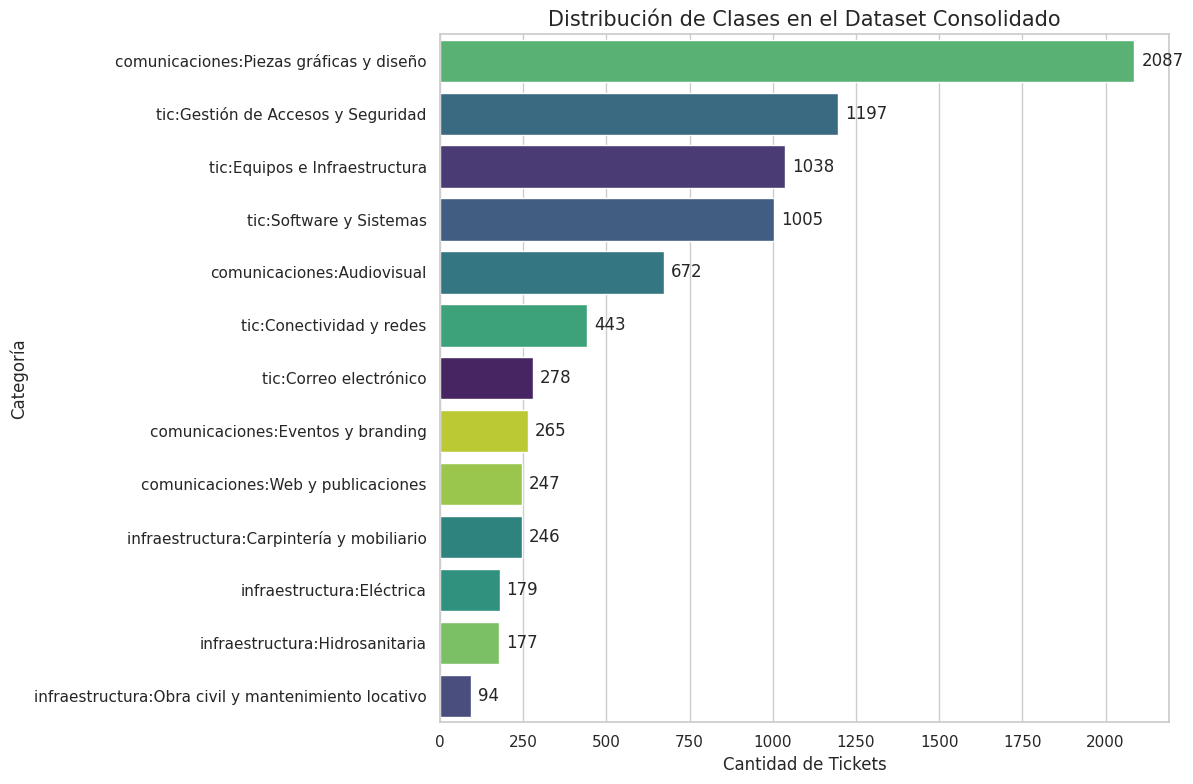

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Crear gráfico de conteo - Corregido para evitar el FutureWarning
ax = sns.countplot(
    data=df,
    y='categoria_label',
    hue='categoria_label',
    order=df['categoria_label'].value_counts().index,
    palette='viridis',
    legend=False
)

# Añadir etiquetas y título
plt.title('Distribución de Clases en el Dataset Consolidado', fontsize=15)
plt.xlabel('Cantidad de Tickets', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Añadir los valores numéricos en las barras para mayor claridad
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

## 3. Entrenar BETO (Trainer plano + early stopping)

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import random
import pandas as pd

# 1. Split Estratificado PRIMERO para evitar LEAKAGE
tr_idx, tmp_idx = train_test_split(df.index, test_size=0.20, random_state=HP["seed"], stratify=df["label_id"])
val_idx, te_idx = train_test_split(tmp_idx, test_size=0.50, random_state=HP["seed"], stratify=df.loc[tmp_idx, "label_id"])

df_train = df.loc[tr_idx].copy()
df_val = df.loc[val_idx].reset_index(drop=True)
df_test = df.loc[te_idx].reset_index(drop=True)

# 2. Data Augmentation SOLO en Train
def augment_technical_text(text):
    synonyms = {'usuario': ['cuenta', 'colaborador'], 'falla': ['error', 'problema'], 'acceso': ['entrada', 'ingreso'], 'equipo': ['pc', 'computador']}
    words = text.split()
    for i, word in enumerate(words):
        w = word.lower().strip(',.')
        if w in synonyms and random.random() > 0.4:
            words[i] = random.choice(synonyms[w])
    return ' '.join(words)

counts = df_train['label_id'].value_counts()
minority_threshold = 80
minority_classes = counts[counts < minority_threshold].index
augmented_rows = []
for l_id in minority_classes:
    class_df = df_train[df_train['label_id'] == l_id]
    for _ in range(2):
        for _, row in class_df.iterrows():
            nr = row.copy()
            nr['texto'] = augment_technical_text(row['texto'])
            augmented_rows.append(nr)

if len(augmented_rows) > 0:
    df_train = pd.concat([df_train, pd.DataFrame(augmented_rows)], ignore_index=True)

print(f"--- Setup Final ---")
print(f"Train (aumentado): {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# 3. Tokenización y Dataset
tokenizer = AutoTokenizer.from_pretrained(HP["model"])

class TicketDS(torch.utils.data.Dataset):
    def __init__(self, d):
        self.enc = tokenizer(d["texto"].tolist(), truncation=True, padding="max_length", max_length=HP["max_length"])
        self.labels = d["label_id"].astype(int).tolist()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

train_ds, val_ds, test_ds = TicketDS(df_train), TicketDS(df_val), TicketDS(df_test)

# 4. Entrenamiento con Argumentos de compatibilidad
model = AutoModelForSequenceClassification.from_pretrained(HP["model"], num_labels=len(id2label), id2label=id2label, label2id=label2id)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"accuracy": accuracy_score(p.label_ids, preds), "macro_f1": f1_score(p.label_ids, preds, average="macro")}

args = TrainingArguments(
    output_dir=str(OUT),
    num_train_epochs=HP["epochs"],
    per_device_train_batch_size=HP["batch"],
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=HP["weight_decay"],
    warmup_steps=10,
    logging_steps=10,
    seed=HP["seed"],
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

--- Setup Final ---
Train (aumentado): 6492 | Val: 793 | Test: 793


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1624, training_loss=0.5010042574642033, metrics={'train_runtime': 664.8074, 'train_samples_per_second': 39.061, 'train_steps_per_second': 2.443, 'total_flos': 1708285672820736.0, 'train_loss': 0.5010042574642033, 'epoch': 4.0})

In [12]:
# eval + reporte
import json
val_m = trainer.evaluate(val_ds)
test_m = trainer.evaluate(test_ds)
print({"val": val_m, "test": test_m})

pred = trainer.predict(test_ds)
y_pred = np.argmax(pred.predictions, axis=1)
y_true = pred.label_ids
labels_present = sorted(set(int(x) for x in y_true) | set(int(x) for x in y_pred))
print(classification_report(y_true, y_pred, labels=labels_present, target_names=[id2label[i] for i in labels_present], zero_division=0))

# guardar
trainer.save_model(str(OUT))
tokenizer.save_pretrained(str(OUT))
with open(OUT / "metrics.json", "w", encoding="utf-8") as f:
    json.dump({"val": val_m, "test": test_m, "hp": HP, "clases": len(id2label)}, f, ensure_ascii=False, indent=2)
with open(OUT / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": {str(k): v for k, v in id2label.items()}}, f, ensure_ascii=False, indent=2)
print(f"guardado en {OUT}")
!ls -lh "$OUT" 2>&1 | head -n 20
!cat "$OUT/metrics.json"

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.237744,0.638775,4,0.793190,0.783876


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.237744,0.674015,4,0.775536,0.746782


{'val': {'eval_loss': 0.6387754082679749, 'eval_accuracy': 0.7931904161412359, 'eval_macro_f1': 0.7838759334083736}, 'test': {'eval_loss': 0.6740146279335022, 'eval_accuracy': 0.7755359394703657, 'eval_macro_f1': 0.7467822027898241}}


                                                     precision    recall  f1-score   support

                         comunicaciones:Audiovisual       0.90      0.93      0.91        67
                  comunicaciones:Eventos y branding       0.73      0.73      0.73        26
            comunicaciones:Piezas gráficas y diseño       0.92      0.94      0.93       209
                 comunicaciones:Web y publicaciones       0.88      0.58      0.70        24
           infraestructura:Carpintería y mobiliario       0.74      0.80      0.77        25
                          infraestructura:Eléctrica       0.77      0.94      0.85        18
                     infraestructura:Hidrosanitaria       0.93      0.78      0.85        18
infraestructura:Obra civil y mantenimiento locativo       0.67      0.80      0.73        10
                           tic:Conectividad y redes       0.80      0.64      0.71        44
                             tic:Correo electrónico       0.43      0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

guardado en /content/ml/models/beto-tickets
total 420M
drwxr-xr-x 2 root root 4.0K Sep 15 22:46 checkpoint-1218
drwxr-xr-x 2 root root 4.0K Sep 15 22:49 checkpoint-1624
drwxr-xr-x 2 root root 4.0K Sep 15 22:40 checkpoint-406
drwxr-xr-x 2 root root 4.0K Sep 15 22:43 checkpoint-812
-rw-r--r-- 1 root root 2.1K Sep 15 23:00 config.json
-rw-r--r-- 1 root root 1.2K Sep 15 23:00 label_mapping.json
-rw-r--r-- 1 root root  470 Sep 15 23:00 metrics.json
-rw------- 1 root root 420M Sep 15 23:00 model.safetensors
-rw-r--r-- 1 root root  405 Sep 15 23:00 tokenizer_config.json
-rw-r--r-- 1 root root 713K Sep 15 23:00 tokenizer.json
-rw-r--r-- 1 root root 5.1K Sep 15 23:00 training_args.bin
{
  "val": {
    "eval_loss": 0.6387754082679749,
    "eval_accuracy": 0.7931904161412359,
    "eval_macro_f1": 0.7838759334083736
  },
  "test": {
    "eval_loss": 0.6740146279335022,
    "eval_accuracy": 0.7755359394703657,
    "eval_macro_f1": 0.7467822027898241
  },
  "hp": {
    "model": "dccuchile/bert-base-

### 🔍 Auditoría de Data Leakage
Vamos a verificar si existen textos idénticos o casi idénticos compartidos entre los sets de entrenamiento, validación y test, lo cual explicaría la precisión perfecta.

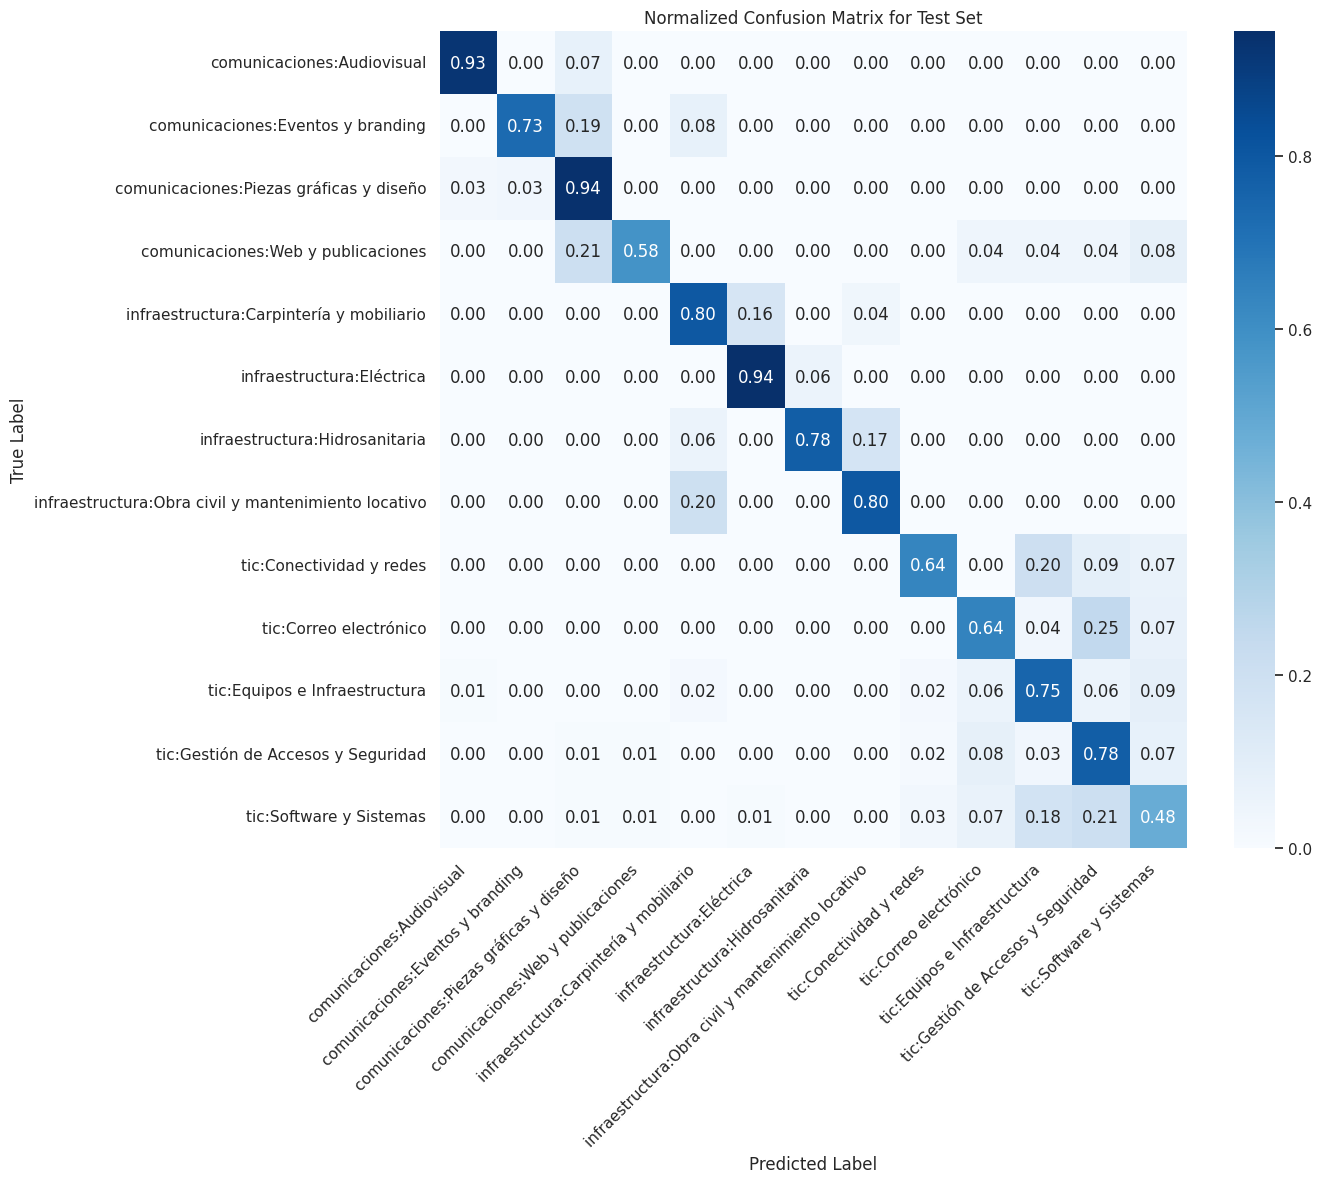

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels_present)

# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plotting the confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=[id2label[i] for i in labels_present], yticklabels=[id2label[i] for i in labels_present])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix for Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Understanding the Confusion Matrix

This normalized confusion matrix shows the proportion of actual labels that were predicted for each class.

*   **Rows** represent the *true* labels of the tickets.
*   **Columns** represent the *predicted* labels by the model.
*   The values range from 0.00 to 1.00, indicating the percentage.

**Key Observations:**
*   **Diagonal values** (from top-left to bottom-right) indicate the proportion of correctly classified instances for each class. Higher values (closer to 1.00) are better.
*   **Off-diagonal values** indicate misclassifications. For example, a value of 0.10 in row A, column B means 10% of tickets that *actually* belonged to class A were *predicted* as class B.

This visualization helps identify which classes the model struggles with the most and which specific classes it confuses them with.

In [14]:
def deep_leakage_audit(df_tr, df_val, df_te):
    def get_overlap(d1, d2):
        s1 = set(d1['texto'].unique())
        s2 = set(d2['texto'].unique())
        return s1.intersection(s2)

    leak_val = get_overlap(df_tr, df_val)
    leak_te = get_overlap(df_tr, df_te)
    leak_v_t = get_overlap(df_val, df_te)

    print(f"--- Auditoría Profunda de Fugas ---")
    print(f"Solapamiento Train-Val: {len(leak_val)} muestras")
    print(f"Solapamiento Train-Test: {len(leak_te)} muestras")
    print(f"Solapamiento Val-Test: {len(leak_v_t)} muestras")

    if len(leak_val) > 0 or len(leak_te) > 0:
        print("\n⚠️ ALERTA: Se detectaron textos idénticos en diferentes sets.")
        print("Esto ocurre si el dataset original tiene duplicados antes del split.")
        print(f"Ejemplo de texto duplicado: {list(leak_val)[0] if leak_val else list(leak_te)[0]}")
    else:
        print("\n✅ No hay textos idénticos cruzados.")

    # Verificar si las clases son demasiado fáciles (p.ej. contienen el nombre de la categoría)
    print("\n--- Análisis de Contenido ---")
    sample_txt = df_tr.iloc[0]['texto']
    print(f"Ejemplo de texto de entrada: '{sample_txt}'")
    print("Si el texto contiene palabras clave obvias como 'tic:Software', el modelo aprenderá instantáneamente.")

deep_leakage_audit(df_train, df_val, df_test)

--- Auditoría Profunda de Fugas ---
Solapamiento Train-Val: 0 muestras
Solapamiento Train-Test: 0 muestras
Solapamiento Val-Test: 0 muestras

✅ No hay textos idénticos cruzados.

--- Análisis de Contenido ---
Ejemplo de texto de entrada: 'Cambio de contraseña G+ [SEP] Cambio de contraseña G+'
Si el texto contiene palabras clave obvias como 'tic:Software', el modelo aprenderá instantáneamente.


In [15]:
print("--- Muestra de df_train (Primeras 15 filas) ---")
display(df_train[['texto', 'categoria_label', 'label_id']].head(15))

print("\n--- Distribución de clases en el set de entrenamiento ---")
print(df_train['categoria_label'].value_counts())

print("\n--- Verificación de textos únicos en Train ---")
print(f"Total filas: {len(df_train)}")
print(f"Textos únicos: {df_train['texto'].nunique()}")

--- Muestra de df_train (Primeras 15 filas) ---


,texto,categoria_label,label_id
0,Cambio de contraseña G+ [SEP] Cambio de contra...,tic:Gestión de Accesos y Seguridad,11
1,Diseño de pieza gráfica para laboratorio de na...,comunicaciones:Piezas gráficas y diseño,2
2,Apoyo a Impuestos [SEP] Buenos Dias Tan amable...,tic:Software y Sistemas,12
3,no me permite el ingreso a macondo [SEP] Bueno...,comunicaciones:Web y publicaciones,3
4,Instalar impresora [SEP] Instalacion de impresora,tic:Software y Sistemas,12
5,cambio de luminaria [SEP] solicitamos cambio d...,infraestructura:Eléctrica,5
6,Solicitud publicación de banner web [SEP] Soli...,comunicaciones:Web y publicaciones,3
7,Cableado de internet sin canalizar [SEP] Buena...,tic:Conectividad y redes,8
8,NOTIFICACION RESOLUCION DE TERMINACION DE BENE...,comunicaciones:Web y publicaciones,3
9,Solicitud División de Cajón en Escritorio [SEP...,infraestructura:Carpintería y mobiliario,4



--- Distribución de clases en el set de entrenamiento ---
categoria_label
comunicaciones:Piezas gráficas y diseño                1669
tic:Gestión de Accesos y Seguridad                      958
tic:Equipos e Infraestructura                           830
tic:Software y Sistemas                                 804
comunicaciones:Audiovisual                              538
tic:Conectividad y redes                                354
infraestructura:Obra civil y mantenimiento locativo     225
tic:Correo electrónico                                  222
comunicaciones:Eventos y branding                       212
comunicaciones:Web y publicaciones                      198
infraestructura:Carpintería y mobiliario                197
infraestructura:Eléctrica                               143
infraestructura:Hidrosanitaria                          142
Name: count, dtype: int64

--- Verificación de textos únicos en Train ---
Total filas: 6492
Textos únicos: 6350


## 4. Exportar / descargar modelo

El modelo ya está en `OUT` (Drive si usaste Drive, `/content/ml/models/...` si subida manual). Elige cómo llevártelo:

In [16]:
from transformers import pipeline
clf = pipeline("text-classification", model=str(OUT), tokenizer=str(OUT), device=0 if torch.cuda.is_available() else -1)
for txt in [

"Creación de cuenta de red para nuevo practicante",
"Desactivación de credenciales por fin de contrato",
"Actualización de cargo en el directorio activo",
"Otorgar permisos de lectura en la carpeta compartida de Finanzas",
"Acceso al módulo de reportes en el ERP",
"Revocar acceso a la base de datos de pruebas",
"Desbloqueo de cuenta de Windows por múltiples intentos fallidos",
"Restablecimiento de contraseña del correo corporativo",
"Reporte de correo sospechoso (Phishing)",
"Ampliación de cuota de almacenamiento del buzón",
"Creación de lista de distribución para el comité de convivencia",
"Configuración de firma corporativa en Outlook",
"Revisión de punto de red inactivo en el puesto 45",
"Intermitencia en la conexión Wi-Fi de la sala de juntas",
"Solicitud de cable de red adicional",
"Solicitud de reemplazo de teclado por teclas defectuosas",
"Ampliación de memoria RAM para equipo de diseño",
"Falla de encendido en la CPU del área de recepción",
"Atasco de papel recurrente en la impresora del segundo piso",
"Solicitud de cambio de tóner negro",
"Configuración de escáner en red para un nuevo equipo",
"Instalación de licencia de Adobe Acrobat Pro",
"Actualización de antivirus en equipo portátil",
"Error al intentar abrir Microsoft Excel",
"Restauración de archivo borrado accidentalmente del disco compartido",
"Solicitud de backup completo antes de formateo de equipo",
"Configuración de copias de seguridad automáticas en la nube",
"Error 500 al intentar liquidar nómina en el sistema interno",
"Falla al generar el reporte mensual en el CRM",
"Inconsistencia de datos en la plataforma de facturación",
"Diseño de banner para la campaña de salud ocupacional",
"Creación de plantilla institucional para presentaciones",
"Adaptación de logo para firmas de correo",
"Grabación y edición del mensaje de fin de año de gerencia",
"Registro fotográfico para el evento de aniversario",
"Subtitulación de video de capacitación interna",
"Actualización del banner principal en la intranet",
"Publicación de noticia sobre nuevos convenios corporativos",
"Corrección de enlace roto en el portal de clientes",
"Solicitud de pendones y material POP para feria universitaria",
"Diseño y producción de escarapelas para el congreso anual",
"Aprobación de uso de marca para patrocinio externo",
"Revisión de tomacorriente sin energía en sala de juntas",
"Cambio de luminaria parpadeante en el pasillo principal",
"Instalación de punto eléctrico adicional en zona de cafetería",
"Reparación de fuga de agua en el lavamanos del baño del piso 3",
"Destape de sifón en la cocina de empleados",
"Revisión de baja presión de agua en los sanitarios",
"Ajuste de bisagras en el archivador del área de contabilidad",
"Reparación de rueda suelta en silla ergonómica",
"Instalación de repisa para documentos en recepción",
"Reparación de filtración de humedad en el techo del cuarto de archivo",
"Resane y pintura de pared rayada en el pasillo",
"Ajuste de cerradura trabada en la puerta de salida de emergencia",
]:
    print(txt, "->", clf(txt, truncation=True)[0])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Creación de cuenta de red para nuevo practicante -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.4159504771232605}
Desactivación de credenciales por fin de contrato -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.7670872807502747}
Actualización de cargo en el directorio activo -> {'label': 'tic:Software y Sistemas', 'score': 0.37128910422325134}
Otorgar permisos de lectura en la carpeta compartida de Finanzas -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.6938443779945374}
Acceso al módulo de reportes en el ERP -> {'label': 'tic:Software y Sistemas', 'score': 0.7155984044075012}
Revocar acceso a la base de datos de pruebas -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.47450733184814453}
Desbloqueo de cuenta de Windows por múltiples intentos fallidos -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.7044952511787415}
Restablecimiento de contraseña del correo corporativo -> {'label': 'tic:Gestión de Accesos y Segurida

### Descargar el Modelo

Dado que el modelo se guardó en el almacenamiento local de Colab (`/content/ml/models/beto-tickets/`), la forma más sencilla de descargarlo es comprimir la carpeta y luego usar la función de descarga de Colab.

In [21]:
# Check the size of the model directory
ROOT = Path("/content")
model_dir= ROOT / "ml" / "models" / "beto-tickets"
print(f"Size of model directory '{model_dir}':")
!du -sh {model_dir}

# Example of using 'gztar' for potentially better compression ratio
# Note: This might not always be faster, test both 'zip' and 'gztar'
# You would replace the existing shutil.make_archive line with this if you want to try it.
# shutil.make_archive(str(OUT.parent / 'beto-tickets_model_gztar'), 'gztar', model_dir)

# Example of moving the zipped file directly to Google Drive
# This assumes you have mounted Google Drive previously
# Replace 'YOUR_DRIVE_PATH' with the actual path in your Google Drive where you want to save it.
# For example: '/content/drive/MyDrive/HelpDesk/ml/models/'
# DRIVETARGET = '/content/drive/MyDrive/YOUR_DRIVE_PATH'
# if Path(DRIVETARGET).exists():
#     !mv "{OUT.parent / zip_file_name}" "{DRIVETARGET}/{zip_file_name}"
#     print(f"Moved {zip_file_name} to Google Drive: {DRIVETARGET}/{zip_file_name}")
# else:
#     print(f"Google Drive target path not found: {DRIVETARGET}")

Size of model directory '/content/ml/models/beto-tickets':
5.4G	/content/ml/models/beto-tickets


In [22]:
import shutil
from google.colab import files

# Ruta de la carpeta del modelo
model_dir = str(OUT)

# Nombre del archivo ZIP de salida
zip_file_name = "beto-tickets_model.zip"

# Crear el archivo ZIP
shutil.make_archive(str(OUT.parent / 'beto-tickets_model'), 'zip', model_dir)

print(f"Modelo comprimido en: {OUT.parent / zip_file_name}")

# Descargar el archivo ZIP
files.download(str(OUT.parent / zip_file_name))

KeyboardInterrupt: 

### Optimize Compression and Download

To optimize the compression process, you can first check the size of the directory you are compressing. Then, you might consider using a different compression format like `gztar` which can sometimes offer better compression ratios, potentially leading to a smaller file size and faster download. Alternatively, if your Google Drive is mounted, you can save the model directly to Drive to bypass the download step entirely.